In [5]:
from natural_pdf import PDF

pdf = PDF("../pdfs/m27.pdf")
page = pdf.pages[1]
# page.show()

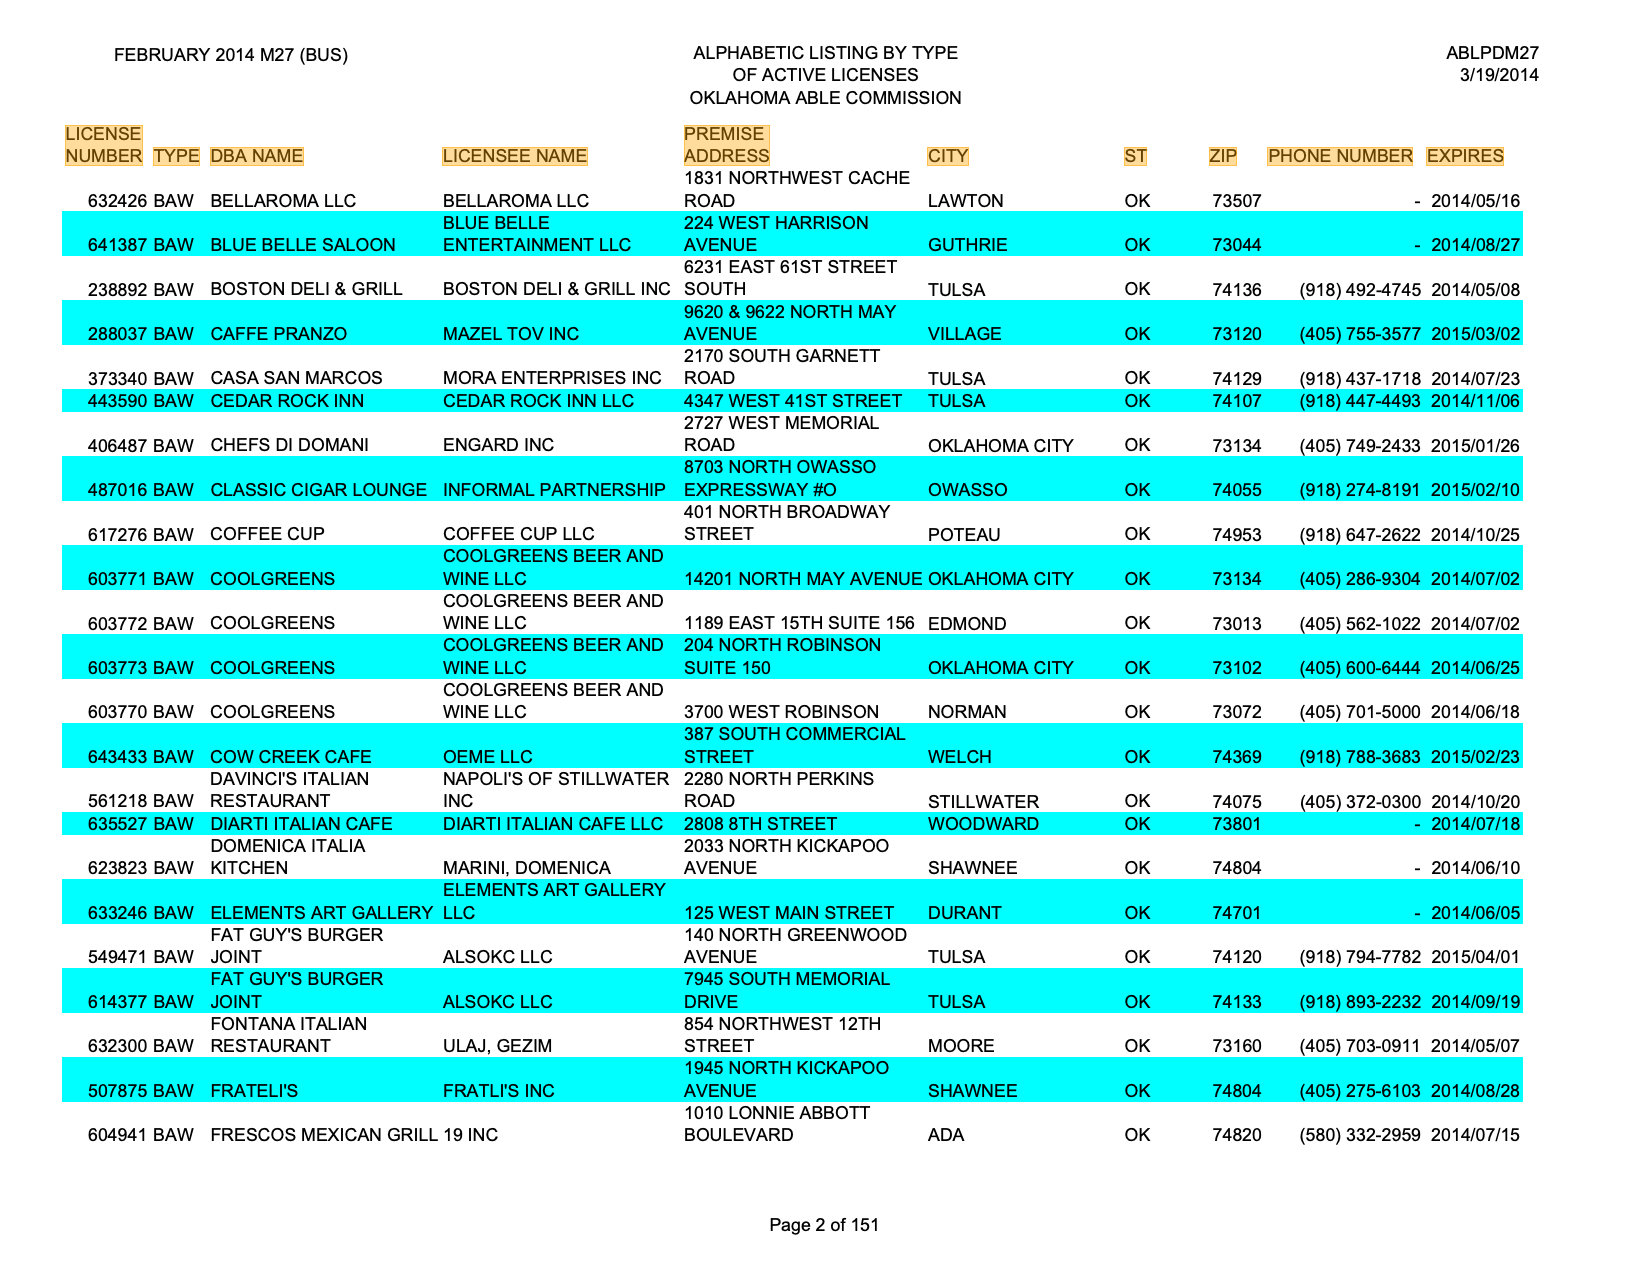

In [6]:
# Explore the page
headers = page.region(top=55, height=30).find_all('text').expand(1).dissolve().expand(-1)
headers.show()

In [7]:
region = page.find("text:contains(LICENSEE NAME)").below(until='text:regex(Page \d)', include_endpoint=False)

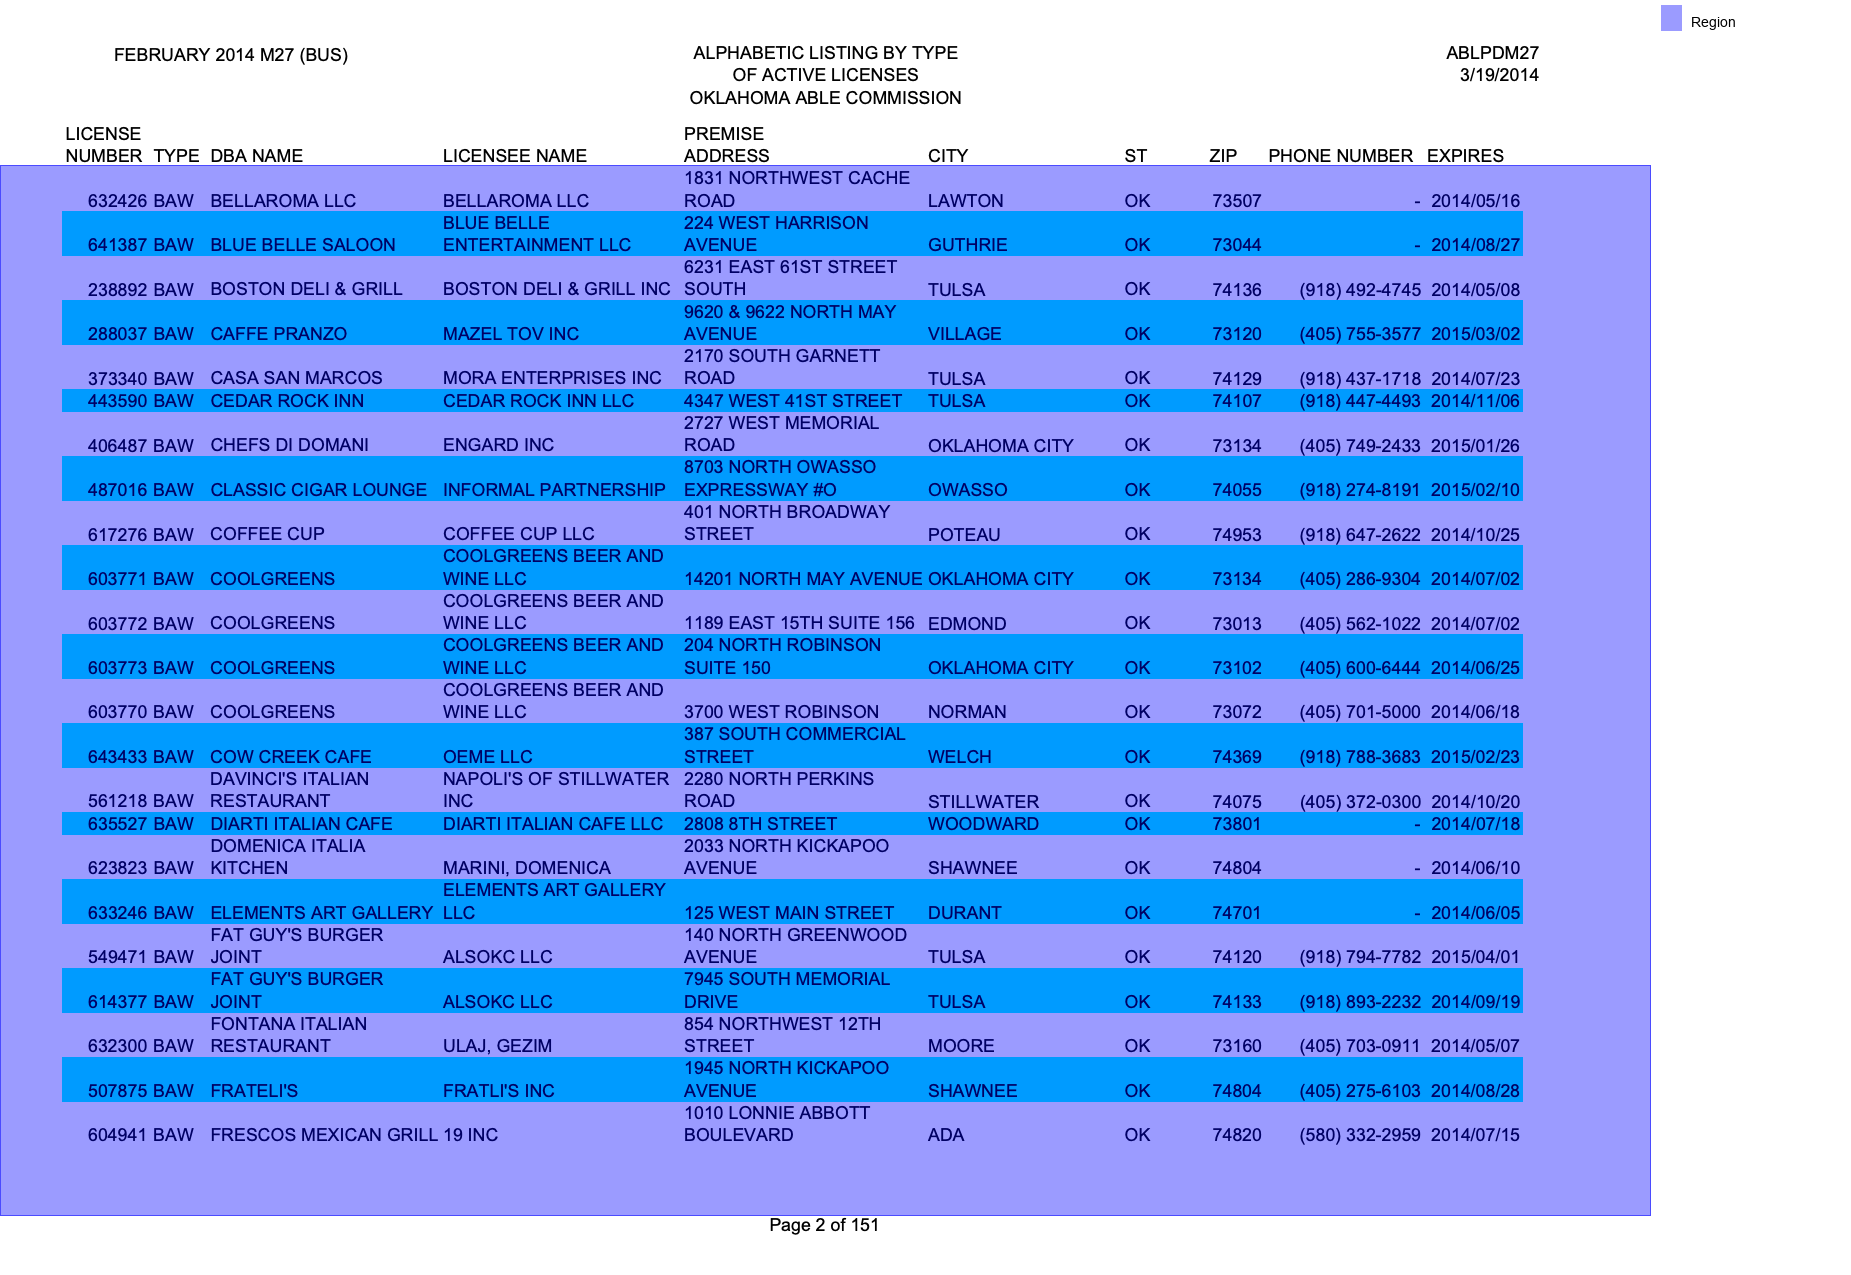

In [8]:
region.show()

In [ ]:
# Extract table with headers as column markers and outer=True for boundaries
# outer=True automatically:
#   1. Adds left/right boundaries to capture all columns
#   2. Detects stripe rectangles (alternating row shading) for row boundaries  
#   3. Adds top/bottom boundaries to capture first/last rows outside stripes
# to_df auto-sorts headers by x0 position when passed an ElementCollection
region.extract_table(
    verticals=headers,
    outer=True
).to_df(header=headers)